In [1]:
import os
import gc
import time
import random
from pathlib import Path

import cv2
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("OpenCV version:", cv2.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
OpenCV version: 4.13.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
dataset_path = Path(
    kagglehub.dataset_download(
        "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
    )
)

image_root = dataset_path / "combined_images"

print("Dataset path:", dataset_path)
print("Image folder:", image_root)
print("Image folder exists:", image_root.exists())

Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images
Image folder exists: True


In [4]:
class_to_binary = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, binary_label in class_to_binary.items():
    class_folder = image_root / class_name

    for image_path in sorted(class_folder.iterdir()):
        if image_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "filepath": str(image_path),
                "original_class": class_name,
                "label": binary_label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))
print("\nBinary class counts:")
print(df["label"].value_counts().sort_index())

print("\nOriginal class counts:")
print(df["original_class"].value_counts())

Total images: 44000

Binary class counts:
label
0    12800
1    31200
Name: count, dtype: int64

Original class counts:
original_class
NonDemented         12800
VeryMildDemented    11200
MildDemented        10000
ModerateDemented    10000
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

initial_train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

initial_validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    stratify=temporary_df["label"],
    random_state=SEED
)

development_df = pd.concat(
    [initial_train_df, initial_validation_df],
    ignore_index=True
)

development_df = development_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Development images:", len(development_df))
print(development_df["label"].value_counts().sort_index())

print("\nUntouched test images:", len(test_df))
print(test_df["label"].value_counts().sort_index())

Development images: 37400
label
0    10880
1    26520
Name: count, dtype: int64

Untouched test images: 6600
label
0    1920
1    4680
Name: count, dtype: int64


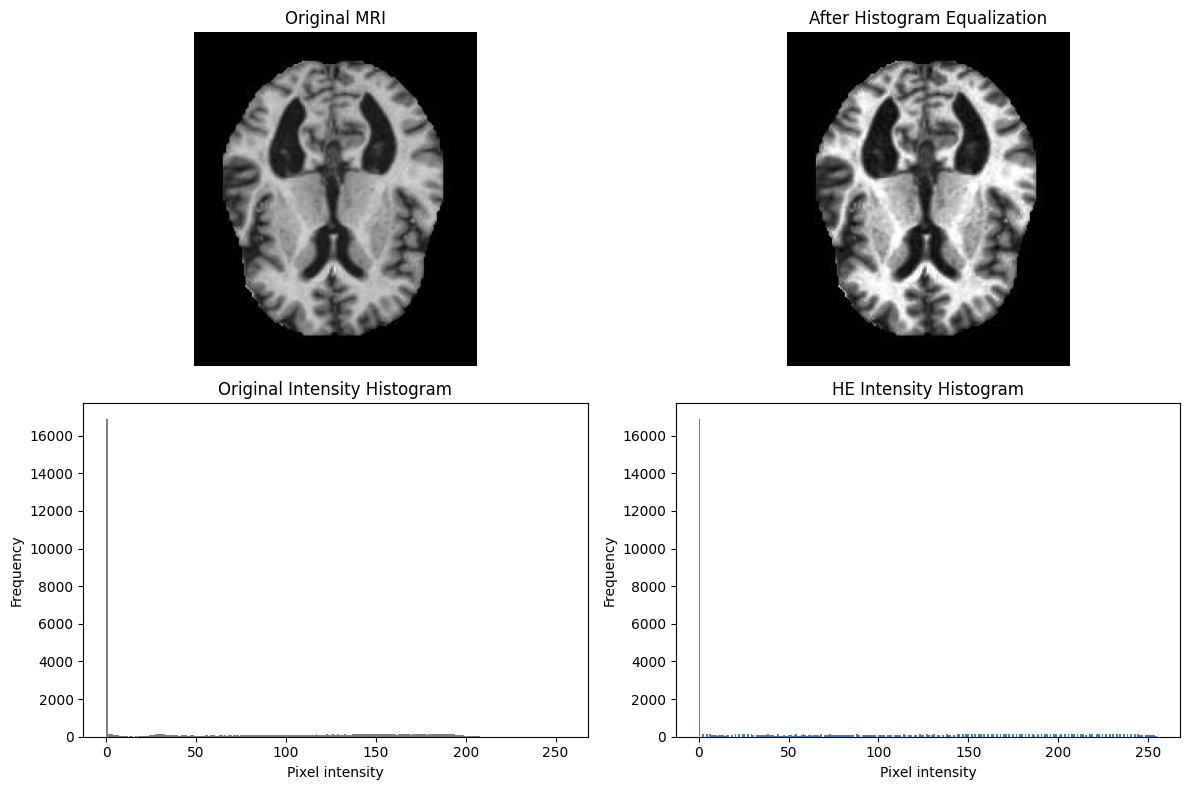

Original pixel range: 0 to 255
HE pixel range: 0 to 255


In [6]:
sample_path = development_df.sample(
    1,
    random_state=SEED
)["filepath"].iloc[0]

original_image = cv2.imread(
    sample_path,
    cv2.IMREAD_GRAYSCALE
)

he_image = cv2.equalizeHist(original_image)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(original_image, cmap="gray")
plt.title("Original MRI")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(he_image, cmap="gray")
plt.title("After Histogram Equalization")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.hist(original_image.ravel(), bins=256, color="gray")
plt.title("Original Intensity Histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")

plt.subplot(2, 2, 4)
plt.hist(he_image.ravel(), bins=256, color="steelblue")
plt.title("HE Intensity Histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print("Original pixel range:", original_image.min(), "to", original_image.max())
print("HE pixel range:", he_image.min(), "to", he_image.max())

In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def apply_he(image):
    image = image.numpy()
    return cv2.equalizeHist(image)


def load_he_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image,
        channels=1,
        expand_animations=False
    )
    image.set_shape([None, None, 1])

    image = tf.squeeze(image, axis=-1)

    image = tf.py_function(
        apply_he,
        [image],
        Tout=tf.uint8
    )
    image.set_shape([None, None])

    image = tf.image.resize(
        image[..., tf.newaxis],
        IMG_SIZE
    )

    image = tf.image.grayscale_to_rgb(image)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)

    return image, label


def create_he_dataset(
    dataframe,
    training=False,
    shuffle_seed=SEED
):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["filepath"].values,
            dataframe["label"].values
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(dataframe), 10000),
            seed=shuffle_seed,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_he_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


test_dataset = create_he_dataset(test_df)

for images, labels in test_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel range:", images.numpy().min(), "to", images.numpy().max())

I0000 00:00:1787771986.296683      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0


In [8]:
from sklearn.model_selection import StratifiedKFold

MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 0.0001
N_FOLDS = 5

cross_validator = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED
)

for fold, (train_indices, validation_indices) in enumerate(
    cross_validator.split(
        development_df,
        development_df["label"]
    ),
    start=1
):
    fold_train_df = development_df.iloc[train_indices]
    fold_validation_df = development_df.iloc[validation_indices]

    print(
        f"Fold {fold}: "
        f"Training = {len(fold_train_df)}, "
        f"Validation = {len(fold_validation_df)}"
    )

print("\nMaximum epochs:", MAX_EPOCHS)
print("Early-stopping patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Preprocessing: HE")
print("Augmentation: Disabled")

Fold 1: Training = 29920, Validation = 7480
Fold 2: Training = 29920, Validation = 7480
Fold 3: Training = 29920, Validation = 7480
Fold 4: Training = 29920, Validation = 7480
Fold 5: Training = 29920, Validation = 7480

Maximum epochs: 30
Early-stopping patience: 5
Learning rate: 0.0001
Preprocessing: HE
Augmentation: Disabled


In [9]:
def build_resnet50(fold_seed):
    tf.keras.utils.set_random_seed(fold_seed)

    resnet_base = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    resnet_base.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))

    x = tf.keras.applications.resnet50.preprocess_input(inputs)
    x = resnet_base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.30)(x)

    outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="ResNet50_HE_NoAug_CV"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


sample_model = build_resnet50(SEED)

print("Total parameters:", sample_model.count_params())
print(
    "Trainable parameters:",
    sum(
        tf.keras.backend.count_params(weight)
        for weight in sample_model.trainable_weights
    )
)
print(
    "ResNet50 frozen:",
    not sample_model.get_layer("resnet50").trainable
)

del sample_model
tf.keras.backend.clear_session()
gc.collect()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Total parameters: 23589761
Trainable parameters: 2049
ResNet50 frozen: True


0

In [10]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

fold_histories = {}
fold_results = []
fold_test_probabilities = []
fold_model_paths = []

print("HE cross-validation storage initialized.")

HE cross-validation storage initialized.


In [11]:
for fold, (train_indices, validation_indices) in enumerate(
    cross_validator.split(
        development_df,
        development_df["label"]
    ),
    start=1
):
    print(
        f"\n{'=' * 20} "
        f"FOLD {fold}/{N_FOLDS} "
        f"{'=' * 20}"
    )

    fold_train_df = development_df.iloc[
        train_indices
    ].reset_index(drop=True)

    fold_validation_df = development_df.iloc[
        validation_indices
    ].reset_index(drop=True)

    train_dataset = create_he_dataset(
        fold_train_df,
        training=True,
        shuffle_seed=SEED + fold
    )

    validation_dataset = create_he_dataset(
        fold_validation_df
    )

    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=fold_train_df["label"]
    )

    fold_class_weights = {
        0: float(weights[0]),
        1: float(weights[1])
    }

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_resnet50(SEED + fold)

    model_path = (
        f"/kaggle/working/"
        f"resnet50_he_noaug_cv_fold_{fold}.keras"
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            model_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

    start_time = time.time()

    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=MAX_EPOCHS,
        class_weight=fold_class_weights,
        callbacks=callbacks,
        verbose=1
    )

    training_minutes = (
        time.time() - start_time
    ) / 60

    history_df = pd.DataFrame(history.history)
    best_index = history_df["val_loss"].idxmin()

    fold_histories[fold] = history_df
    fold_model_paths.append(model_path)

    validation_probabilities = model.predict(
        validation_dataset,
        verbose=0
    ).ravel()

    validation_predictions = (
        validation_probabilities >= 0.5
    ).astype(int)

    validation_labels = fold_validation_df[
        "label"
    ].to_numpy()

    fold_results.append({
        "Fold": fold,
        "Epochs Trained": len(history_df),
        "Best Epoch": best_index + 1,
        "Training Loss": history_df.loc[
            best_index, "loss"
        ],
        "Training Accuracy": history_df.loc[
            best_index, "accuracy"
        ],
        "Validation Loss": history_df.loc[
            best_index, "val_loss"
        ],
        "Validation Accuracy": accuracy_score(
            validation_labels,
            validation_predictions
        ),
        "Precision": precision_score(
            validation_labels,
            validation_predictions
        ),
        "Recall": recall_score(
            validation_labels,
            validation_predictions
        ),
        "F1-score": f1_score(
            validation_labels,
            validation_predictions
        ),
        "ROC-AUC": roc_auc_score(
            validation_labels,
            validation_probabilities
        ),
        "Training Minutes": training_minutes
    })

    fold_test_probabilities.append(
        model.predict(
            test_dataset,
            verbose=0
        ).ravel()
    )

    print(
        f"Fold {fold} completed in "
        f"{training_minutes:.2f} minutes"
    )

    del model, train_dataset, validation_dataset
    tf.keras.backend.clear_session()
    gc.collect()


==================== FOLD 1/5 ====================
Epoch 1/30
  3/935 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step - accuracy: 0.4601 - loss: 0.9960   

I0000 00:00:1787772073.618048     138 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.5441 - loss: 0.7669
Epoch 1: val_loss improved from None to 0.55930, saving model to /kaggle/working/resnet50_he_noaug_cv_fold_1.keras

Epoch 1: finished saving model to /kaggle/working/resnet50_he_noaug_cv_fold_1.keras
935/935 ━━━━━━━━━━━━━━━━━━━━ 173s 172ms/step - accuracy: 0.5971 - loss: 0.7015 - val_accuracy: 0.7167 - val_loss: 0.5593 - learning_rate: 1.0000e-04
Epoch 2/30
935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6602 - loss: 0.6174
Epoch 2: val_loss did not improve from 0.55930
935/935 ━━━━━━━━━━━━━━━━━━━━ 81s 86ms/step - accuracy: 0.6743 - loss: 0.6034 - val_accuracy: 0.7151 - val_loss: 0.5597 - learning_rate: 1.0000e-04
Epoch 3/30
935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6970 - loss: 0.5738
Epoch 3: val_loss improved from 0.55930 to 0.51446, saving model to /kaggle/working/resnet50_he_noaug_cv_fold_1.keras

Epoch 3: finished saving model to /kaggle/working/resnet50_he_noaug_cv_fold_1.keras
935